In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse

# Parameters

In [2]:
L = 1000
N = 50

#reservoir parameters:
p = 10.11 #normalised injection current
eta = 0.0008*0 #input strength 
alpha = 3 #linewidth enhancemenet factor
phi = 0.0 #phase shift
kappa = 10**8*0

task_seed = 0
mask_seed = 42

g = 1.0
ridge_alpha = 1e-4
split = 0.8

theta = 10**-10
dt = 10**-11

TDM_parameters = compute_tdm_params(N, theta, dt)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=50, theta=1e-10, dt=1e-11, T=5e-09, tau=5.0500000000000006e-09, Nd_loop=500, Nd_delay=505, tap_stride=10)


# task import

In [3]:
task = make_static_sin_task(L=L, seed=task_seed)
x, y = task.x, task.y


# masked Input V_ln

In [4]:
#debug standardised mask check:

#maks = generate_mask(N, mask_seed)
#standard_maks = standardise(maks)

#print(maks)

#seems fine

In [5]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) # V is really the output only care about here.

# Masked input Vln -> V(steps) ie convert to a 1d array as (function of steps)

In [6]:
#tap_stride = 5
#Nd = N * tap_stride
#Vs = empty array size LxNxtap_stride
'''
Pseudocode

for l in 0 to L
    for n in 0 to N
        for steps in n*tap_stride to (n+1)*tap_stride

            Vs(steps + l*Nd) = V(l,n)
'''
#'''
def expand_virtual_nodes(V, tap_stride, Nd):

    L, N = V.shape
    #Nd = N * tap_stride

    Vs = np.zeros(L * Nd)

    for l in range(L):
        for n in range(N):
            for step in range(n * tap_stride, (n + 1) * tap_stride):
                Vs[step + l * Nd] = V[l, n]

    return Vs

#'''
'''
def expand_virtual_nodes(V, tap_stride, Nd):
    L, N = V.shape
   # Nd = N * tap_stride

    # Repeat each column tap_stride times along time axis
    V_expanded = np.repeat(V, tap_stride, axis=1)

    # Flatten into single time series
    Vs = V_expanded.reshape(L * Nd)

    return Vs

'''

'\ndef expand_virtual_nodes(V, tap_stride, Nd):\n    L, N = V.shape\n   # Nd = N * tap_stride\n\n    # Repeat each column tap_stride times along time axis\n    V_expanded = np.repeat(V, tap_stride, axis=1)\n\n    # Flatten into single time series\n    Vs = V_expanded.reshape(L * Nd)\n\n    return Vs\n\n'

In [7]:
#debug expand_virtual_nodes

xpandedV = expand_virtual_nodes(V, tap_stride, Nd_loop)

print(xpandedV.shape)

(500000,)


In [8]:
print(xpandedV[0])
print(xpandedV[100])
print(xpandedV[200])
print(xpandedV[300])
#

0.32650105571954696
0.15642483393797763
0.3198068519882142
0.3141853217861185


In [9]:
print(V.shape)
print(V[0])

#Vs is Expanding correctly

(1000, 50)
[0.32650106 0.18514523 0.36220807 0.29419164 0.03972965 0.41157599
 0.32109435 0.33160904 0.05404601 0.18999979 0.15642483 0.39096503
 0.2716209  0.34709017 0.18705869 0.09586291 0.23395711 0.02692194
 0.34914444 0.26647391 0.31980685 0.14956031 0.40949861 0.37677203
 0.32836882 0.08211027 0.1968909  0.01847905 0.06508856 0.28815099
 0.31418532 0.4081536  0.13745267 0.15628211 0.19808679 0.07993038
 0.05480868 0.20068085 0.09572397 0.28256769 0.18441688 0.35127358
 0.2954138  0.13177497 0.35109707 0.33949785 0.16346161 0.12163408
 0.28791752 0.05895597]


In [10]:
print(xpandedV[99*tap_stride])

-0.12135384649837745


In [11]:
print(V[1])

[-0.6720635  -0.38109939 -0.74556214 -0.60555842 -0.08177875 -0.84718011
 -0.66093445 -0.68257769 -0.11124727 -0.39109191 -0.32198187 -0.8047549
 -0.55909925 -0.71444374 -0.38503801 -0.19732238 -0.48157282 -0.05541561
 -0.71867221 -0.54850477 -0.65828428 -0.30785206 -0.84290408 -0.7755403
 -0.67590807 -0.16901421 -0.40527644 -0.03803693 -0.13397703 -0.59312447
 -0.64671303 -0.84013553 -0.28292993 -0.3216881  -0.40773804 -0.16452715
 -0.11281713 -0.41307761 -0.19703637 -0.58163192 -0.37960017 -0.72305478
 -0.60807409 -0.27124308 -0.72269147 -0.69881585 -0.33646623 -0.25036925
 -0.59264388 -0.12135385]


# DDE + RK4 functions 

In [12]:
def ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta):
  
  
    I = abs(E)**2  

   # dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)
    dEdt = ((1.0 + 1j*alpha) * E*n ) - (I * E) + (kappa * E_delay * np.exp(1j*phi))

    dndt = p + (eta * v_slot) - ((1.0 + I) * n)

    return dEdt, dndt


In [13]:
def rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta):
    
   # One RK4 step. v should be v over tap_stride duration. 
 
    # k1
    k1_E, k1_n = ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k2
    E2 = E + 0.5 * dt * k1_E
    n2 = n + 0.5 * dt * k1_n
    k2_E, k2_n = ODEs(E2, n2, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k3
    E3 = E + 0.5 * dt * k2_E
    n3 = n + 0.5 * dt * k2_n
    k3_E, k3_n = ODEs(E3, n3, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k4
    E4 = E + dt * k3_E
    n4 = n + dt * k3_n
    k4_E, k4_n = ODEs(E4, n4, E_delay, v_slot, alpha, kappa, phi, p, eta)


    E_next = E + (dt/6.0) * (k1_E + 2*k2_E + 2*k3_E + k4_E)
    n_next = n + (dt/6.0) * (k1_n + 2*k2_n + 2*k3_n + k4_n)

    return E_next, n_next


# Running ODE

In [14]:

def simulate_lk(Vs, dt, Nd_delay, *, alpha, kappa, phi, p, eta, E0=1e-3+0j, n0=0.0):
    Vs = np.asarray(Vs, dtype=float)
    T_steps = Vs.size

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

    # delay buffer holds E(t - tau)
    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0 #Index pointer for delay buffer

    E, n = E0, n0
    for t in range(T_steps):
        v_slot = float(Vs[t])
        E_delay = delay_buf[di]

        E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta)

        E_hist[t] = E
        n_hist[t] = n

        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist


def extract_R_from_E(E_hist, L, N, tap_stride, Nd_loop):
    R = np.zeros((L, N), dtype=float)
    for l in range(L):
        base = l * Nd_loop
        for n in range(N):
            t_idx = base + (n + 1) * tap_stride - 1  # end of slot
            R[l, n] = np.abs(E_hist[t_idx])**2
    return R



In [15]:
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau


Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, E0=1e-3+0j, n0=0.0)
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)
print("R shape:", R.shape)  # should be (L, N)
print(Vs)



R shape: (1000, 50)
[ 0.32650106  0.32650106  0.32650106 ... -0.06722717 -0.06722717
 -0.06722717]


In [16]:

print(Vs[(Nd_loop*L)-2])
print(Vs.shape)

-0.06722716783543722
(500000,)


In [17]:
'''
#step = np.zeros(L*Nd_loop)

#for i in range(L*Nd_loop):
 #   step[i] = i

#print(step[(L*Nd_loop)])

plt.figure(figsize=(10,4))
plt.plot(step, Vs)
plt.xlabel("step")
plt.ylabel("Vs(t)")
plt.title("Expanded Masked Input Signal Vs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(Vs, label="True")
plt.xlabel("step")
plt.ylabel("Vs(t)")
plt.title("Expanded Masked Input Signal Vs")
#plt.plot(y_pred[:200], "--", label="Pred")
#plt.legend()
plt.tight_layout()
plt.show()
'''

'\n#step = np.zeros(L*Nd_loop)\n\n#for i in range(L*Nd_loop):\n #   step[i] = i\n\n#print(step[(L*Nd_loop)])\n\nplt.figure(figsize=(10,4))\nplt.plot(step, Vs)\nplt.xlabel("step")\nplt.ylabel("Vs(t)")\nplt.title("Expanded Masked Input Signal Vs")\nplt.tight_layout()\nplt.show()\n\nplt.figure(figsize=(8,4))\nplt.plot(Vs, label="True")\nplt.xlabel("step")\nplt.ylabel("Vs(t)")\nplt.title("Expanded Masked Input Signal Vs")\n#plt.plot(y_pred[:200], "--", label="Pred")\n#plt.legend()\nplt.tight_layout()\nplt.show()\n'

MSE: 0.5283478090093371
NRMSE: 1.0005198979726286


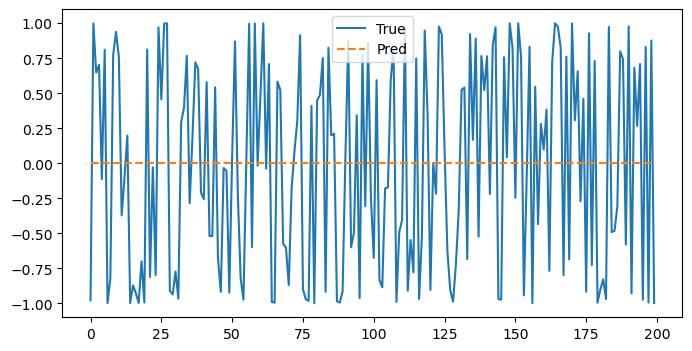

In [18]:
s = split_states_targets(R, y, split=split)
model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
y_pred = predict_readout(model, s.R_test)

print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test[:1000], label="True")
plt.plot(y_pred[:1000], "--", label="Pred")
plt.legend()
plt.show()

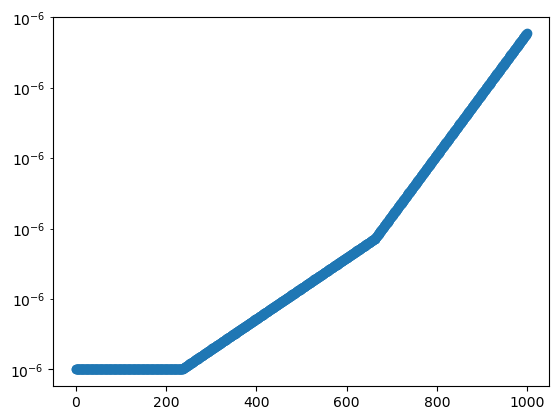

In [19]:
plt.semilogy(R[:,0],'o')
plt.show()



In [20]:
print(R.shape)

(1000, 50)


In [21]:
#np.savetxt("R.txt", R.view(float))

In [22]:
#np.savetxt("R_real.csv", R.real, delimiter=",")
#np.savetxt("R_imag.csv", R.imag, delimiter=",")

### scipy complexODE attempt

In [23]:
'''
def lk_rhs(t, y, delay_buf, di, v_slot, alpha, kappa, phi, p, eta):

    E = y[0]
    n = y[1].real  

    E_delay = delay_buf[di]  

    I = np.abs(E)**2
    dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)
    dndt = p + eta * v_slot - (1.0 + I) * n

    return np.array([dEdt, dndt + 0j], dtype=np.complex128)


def simulate_lk_new(
    Vs, dt, Nd_delay, *,
    alpha, kappa, phi, p, eta,
    E0=1e-3+0j, n0=0.0,
    rtol=1e-6, atol=1e-9,
    integrator="dopri5",
    nsteps=10000
):
    Vs = np.asarray(Vs, dtype=float)
    T_steps = Vs.size

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

  
    Nd_delay = int(Nd_delay)
    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0

   
    y0 = np.array([E0, n0 + 0j], dtype=np.complex128)

    solver = complex_ode(lk_rhs)
    solver.set_integrator(
        integrator,
        rtol=rtol,
        atol=atol,
        first_step=dt,
        max_step=dt,     
        nsteps=nsteps
    )
    solver.set_initial_value(y0, t=0.0)

    for k in range(T_steps):
        v_slot = float(Vs[k])
        t0 = solver.t

        
        solver.set_f_params(delay_buf, di, v_slot, alpha, kappa, phi, p, eta)

        y_next = solver.integrate(t0 + dt)
       
        E = y_next[0]
        n = y_next[1].real

        E_hist[k] = E
        n_hist[k] = n

     
        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist
'''

'\ndef lk_rhs(t, y, delay_buf, di, v_slot, alpha, kappa, phi, p, eta):\n\n    E = y[0]\n    n = y[1].real  \n\n    E_delay = delay_buf[di]  \n\n    I = np.abs(E)**2\n    dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)\n    dndt = p + eta * v_slot - (1.0 + I) * n\n\n    return np.array([dEdt, dndt + 0j], dtype=np.complex128)\n\n\ndef simulate_lk_new(\n    Vs, dt, Nd_delay, *,\n    alpha, kappa, phi, p, eta,\n    E0=1e-3+0j, n0=0.0,\n    rtol=1e-6, atol=1e-9,\n    integrator="dopri5",\n    nsteps=10000\n):\n    Vs = np.asarray(Vs, dtype=float)\n    T_steps = Vs.size\n\n    E_hist = np.zeros(T_steps, dtype=np.complex128)\n    n_hist = np.zeros(T_steps, dtype=float)\n\n  \n    Nd_delay = int(Nd_delay)\n    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)\n    di = 0\n\n   \n    y0 = np.array([E0, n0 + 0j], dtype=np.complex128)\n\n    solver = complex_ode(lk_rhs)\n    solver.set_integrator(\n        integrator,\n        rtol=rtol,\n        atol=atol,\n        fi

In [24]:
'''
E_hist, n_hist = simulate_lk_new(
    Vs, dt, Nd_delay,
    alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta,
    E0=1e-3+0j, n0=0.0
)

R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)
print("R shape:", R.shape)  # (L, N)
'''

'\nE_hist, n_hist = simulate_lk_new(\n    Vs, dt, Nd_delay,\n    alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta,\n    E0=1e-3+0j, n0=0.0\n)\n\nR = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)\nprint("R shape:", R.shape)  # (L, N)\n'